In [1]:
import cv2
from matplotlib import pyplot as plt
from pathlib import Path

import src.ModelTrain as ModelTrain

In [2]:
F1_FIG_NAME = 'f1_score_evolution.png'
LOSS_FIG_NAME = 'loss_evolution.png'
CONF_MATRIX_NAME = 'confusion_matrix.png'

**Phase 1**

In [ ]:
# This configuration is used on the baseline model, and fixed for all the experiments in the project. 
# Doing this we ensure that the evolution of the results is only due to the changes in the data.
baseline_train = ModelTrain.TrainingConfig(    
    train_ratio=0.8,
    random_state=42,
    input_size=224, # Standard input size for EfficientNet
    val_resize_size=256,
    batch_size=32,
    num_workers=0,
    num_epochs=100,

    warmup_epochs=0, # No fine-tuning phase, the whole network is being trained from the beginning
    trainable_backbone_blocks=3, # Unused on this case (warmup_epochs=0)
    enable_backbone_finetuning=True,
    full_network_finetuning=True,

    head_lr=1e-3, # Unused on this case (no fine-tuning phase)
    fine_tune_head_lr=1e-4,
    backbone_lr=1e-5,

    weight_decay=5e-4,
    dropout=0.3,
    stochastic_depth_prob=0.1,
    label_smoothing=0.02,

    scheduler_factor=0.5, # Modifies the learning rate by multiplying it by this factor when the F1-macro metric don't improve for a certain number of epochs (scheduler_patience).
    scheduler_patience=2, 
    early_stopping_patience=10,
    min_lr=1e-6, 
    gradient_clip_norm=1.0,

    use_weighted_loss=True,
    use_weighted_sampler=False, # Using also a weighted sampler overrepresents the minority classes, leading to overfitting.
    )

Hardware assigned for tensor computations: cuda
Train class distribution:
histology
Adenoma                     1555
Sessile_serrated_adenoma     660
Hyperplastic                 337
Adenocarcinoma                97

Validation class distribution:
histology
Adenoma                     339
Sessile_serrated_adenoma    179
Hyperplastic                 62
Adenocarcinoma               23

Loss weights: {'Adenoma': 0.4605, 'Sessile_serrated_adenoma': 0.7068, 'Hyperplastic': 0.9891, 'Adenocarcinoma': 1.8436}
Initiating training phase. Saving results to: C:\Users\luis\Documents\TFG - Data-Centric AI\results\baseline_experiment


Training Progress:   0%|          | 0/100 [00:00<?, ?epoch/s]


Switching to full-network fine-tuning at epoch 1.


Training Progress:  39%|███▉      | 39/100 [44:04<1:08:56, 67.81s/epoch, Stage=full_network, Train Loss=0.5112, Val Loss=1.1614, Val F1=0.5168, LR=1.0e-06/1.6e-06]        
c:\Users\luis\Documents\TFG - Data-Centric AI\src\ModelTrain.py:725: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full 


Early stopping triggered after 10 epochs without improving macro-F1.

Optimization sequence completed. Best validation macro-F1: 0.5412 at epoch 30.
Artifacts successfully written to 'C:\Users\luis\Documents\TFG - Data-Centric AI\results\baseline_experiment'.


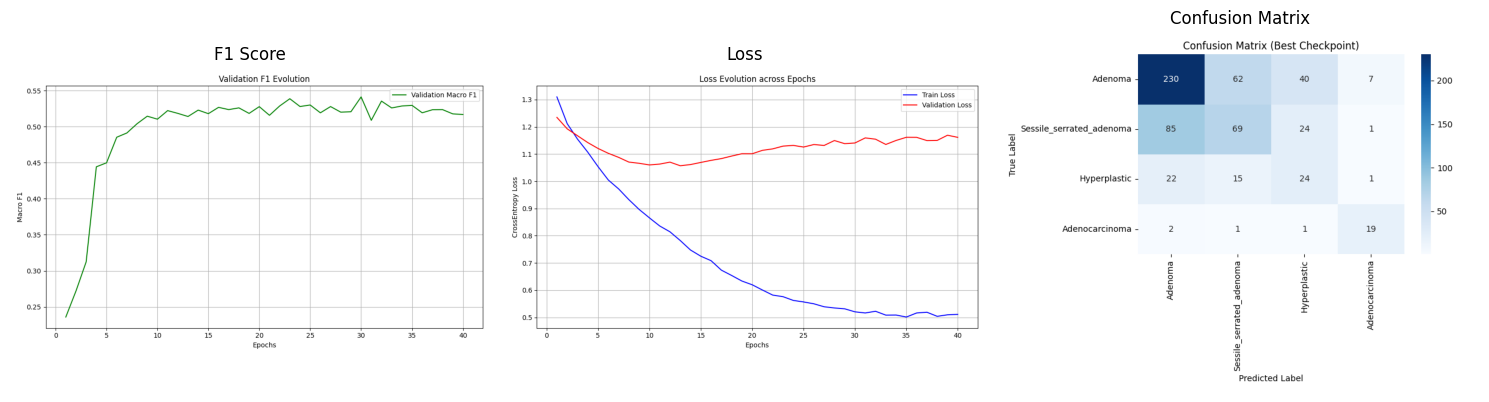

In [4]:
baseline_img_dir = Path('unified_images')
baseline_csv_dir = Path('unified_data_baseline.csv')
results_dir = Path('baseline_experiment')

trained_model, validation_loader = ModelTrain.train(baseline_csv_dir, baseline_img_dir, results_dir, baseline_train)

results_path = ModelTrain.RESULTS_DIR / Path(results_dir)
image_paths = [results_path / F1_FIG_NAME, results_path / LOSS_FIG_NAME, results_path / CONF_MATRIX_NAME]

titles = ["F1 Score", "Loss", "Confusion Matrix"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, img_path, title in zip(axes, image_paths, titles):
    # Carga de la imagen
    img = cv2.imread(str(img_path))
    
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
    else:
        ax.text(0.5, 0.5, 'Error: Image not found', fontsize=12, color='red',ha='center', va='center', transform=ax.transAxes)
        
    ax.set_title(title, fontsize=12)
    ax.axis('off') 

plt.tight_layout()
plt.show()